## REDES NEURONALES
-  Autor: Germán Homero Morán Figueroa
- Descripción: Este notebook permite realizar el entrenamiento de una red Neuronal y verificar los resultados de desempeño teniendo en cuenta diferentes datasets de entrada.

    * Dataset Original Construido con la vista minable
    * Dataset con las  20 caracteristicas mas relevantes.
    * Dataset con las 50 caracteristicas mas relevantes.

- Salida: Desempeño comparativo de los modelos con diferentes datasets, previamente realizando seleccion de atributos

In [1]:

# Librerias y Dependencias
# =================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

C:\Users\germanm\AppData\Roaming\Python\Python39\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\germanm\AppData\Roaming\Python\Python39\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# Callback para mostrar el progreso de cada época
class PrintDot(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs):
        if epoch % 100 == 0:
            print('')
        print('.', end='')




# Definición Arquitectura Red Neuronal
# ========================================================

def build_model(dataset):
  model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=[len(dataset.keys())]),
    layers.Dense(64, activation='relu'),
    layers.Dense(1)
  ])

  optimizer = tf.keras.optimizers.Adam(0.001)

  model.compile(loss='mse',
                optimizer=optimizer,
                metrics=['mae', 'mse'])
  return model


# Graficos de desempeño MSE y MAE
# ============================================
def plot_history(history):
  hist = pd.DataFrame(history.history)
  hist['epoch'] = history.epoch

  plt.figure()
  plt.xlabel('Epoch')
  plt.ylabel('Mean Abs Error [RDT_AJS]')
  plt.plot(hist['epoch'], hist['mae'],
           label='Train Error')
  plt.plot(hist['epoch'], hist['val_mae'],
           label = 'Val Error')

  plt.legend()

  plt.figure()
  plt.xlabel('Epoch')
  plt.ylabel('Mean Square Error [RDT_AJS]')
  plt.plot(hist['epoch'], hist['mse'],
           label='Train Error')
  plt.plot(hist['epoch'], hist['val_mse'],
           label = 'Val Error')

  plt.legend()
  plt.show()


def entrenamiento_modelo(model, X_train,y_train):
    # Resumen del modelo
    model.summary()



    # Definir el EarlyStopping callback
    # Se incluye el parametro early stop para detener el entrenamiento en caso de no mejorar
    #  =================================================================================
    early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=100)
    EPOCHS = 1000


    # Entrenamiento 
    # ====================================================================
    history = model.fit(
        X_train,                    # Datos normalizados de entrenamiento
        y_train,                    # Etiquetas de entrenamiento
        epochs=EPOCHS,              # Número total de épocas
        validation_split=0.2,       # Proporción de los datos para validación
        callbacks=[PrintDot(), early_stop]  # Incluir ambos callbacks
    )

    return history , model
def calcular_metricas(y_test, y_pred):
    """
    Calcula R², MAE y MSE para un modelo de Keras y devuelve los resultados en un DataFrame.

    Parámetros:

        y_pred: Predicciones reales realziadas por el modelo
        y_test: Valores reales del conjunto de prueba.

    Retorna:
        DataFrame con las métricas calculadas.
    """


    # Calcular métricas
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)

    # Crear un DataFrame con los resultados
    df_resultados = pd.DataFrame({
        "Métrica": ["R²", "MAE", "MSE"],
        "Valor": [r2, mae, mse]
    })

    return df_resultados




# Procesamiento al conjunto de datos
# ===========================================================

def procesamiento_features(X, Y, features):

    if len(features)== 0:
        X_Features = X
    
    else:
        print("Cantidad de caracteristicas: ", len(features)) 
        X_Features = X[features]

    
    X_train, X_test, y_train, y_test = train_test_split(X_Features, Y, test_size=0.2, random_state=42)
    scaler = StandardScaler()
    X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_Features.columns)
    X_test  = pd.DataFrame(scaler.fit_transform(X_test), columns=X_Features.columns)

    return X_train, X_test, y_train, y_test



def scater_predictions (y_test, y_pred):
    # Calcular los errores absolutos para asignar colores
    errors = np.abs(y_test - y_pred)

    # Crear scatter plot con colores según el error
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(y_test, y_pred, c=errors, cmap='coolwarm', alpha=0.75, edgecolors="k")

    # Agregar etiquetas
    plt.xlabel('True Values [RDT_AJUST]')
    plt.ylabel('Predictions [RDT_AJUST]')
    plt.title('Valores Predichos vs. Valores Reales')

    # Hacer que los ejes tengan la misma escala
    plt.axis('equal')
    plt.axis('square')

    # Definir límites en x e y
    plt.xlim([0, plt.xlim()[1]])
    plt.ylim([0, plt.ylim()[1]])

    # Agregar línea de referencia (y=x)
    plt.plot([-100, 100], [-100, 100], 'k--', linewidth=2)

    # Agregar barra de colores para interpretar el error
    cbar = plt.colorbar(scatter)
    cbar.set_label("Error Absoluto")


    plt.show()

### Analisis 20 caracteristicas mas relevantes


In [3]:
# Lectura de los datos.
# ==========================================================
#df = pd.read_excel("../../Data/Gold/DatasetFinal.xlsx")
df = pd.read_csv("../../Data/Gold/DatasetFinalFP.csv")

# FEATURE 20 
# ===========================================================
car = pd.read_excel("../../Data/Silver/Otros/resultados_sa.xlsx",sheet_name="k_features_1_2")
features_20 = list(car.Features.values)

In [92]:
# Selección de las variables categoricas
# =========================================================
cat_features = df.select_dtypes(include = ["object", "category"]).columns
df_cat = pd.get_dummies(df[cat_features], drop_first = True, dummy_na = True, dtype=int)
df.drop(cat_features, axis = 1, inplace = True)
df_final = pd.concat([df,df_cat], axis = 1)

# División Features | Variable objetivo
# ===========================================================
Y = df_final.RDT_AJUSTADO
X = df_final.drop(["RDT_AJUSTADO","ID_LOTE"], axis=1)

### 1. Dataset completo
**Nota** En este caso se envia el datset original tal como viene del origen 

In [95]:

# Definición datos Train and Testo
# ===========================================
features = []
X_train, X_test, y_train, y_test = procesamiento_features (X, Y ,features)
# Contrucción del modelo
# ===========================================
model = build_model(X_train)
history, best_model = entrenamiento_modelo(model, X_train, y_train)


C:\Users\germanm\AppData\Roaming\Python\Python39\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 64)             │        12,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,257 (63.50 KB)

 Trainable params: 16,257 (63.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/1000
 1/16 ━━━━━━━━━━━━━━━━━━━━ 44s 3s/step - loss: 26670920.0000 - mae: 4981.3789 - mse: 26670920.0000
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 25383418.0000 - mae: 4846.0889 - mse: 25383418.0000 - val_loss: 24629120.0000 - val_mae: 4783.6934 - val_mse: 24629120.0000
Epoch 2/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 23912816.0000 - mae: 4697.7109 - mse: 23912816.0000 - val_loss: 24589112.0000 - val_mae: 4779.6792 - val_mse: 24589112.0000
Epoch 3/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 24039318.0000 - mae: 4715.7949 - mse: 24039318.0000 - val_loss: 24515780.0000 - val_mae: 4772.4585 - val_mse: 24515780.0000
Epoch 4/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 24472626.0000 - mae: 4767.6333 - mse: 24472626.0000 - val_loss: 24383800.0000 - val_mae: 4759.6504 - val_mse: 24383800.0000
Epoch 5/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 24431776.0000 - mae: 4734.6489 - mse: 24431776.0000 - val_loss: 24158828.0000 - val_mae: 4737.9478 - val

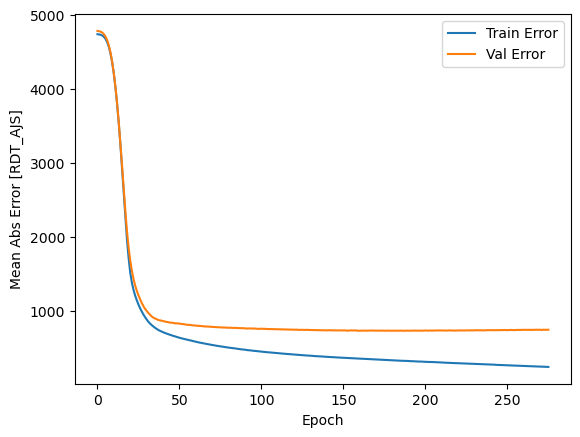

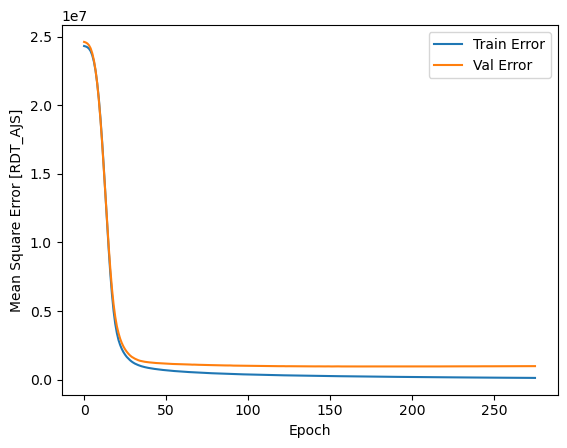

In [96]:
#  Resumen del entranamiento
# ========================================
hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch
hist.tail()

# Grafias de desempeño
# =========================================
plot_history(history)

5/5 - 0s - 13ms/step - loss: 1047478.8125 - mae: 796.4460 - mse: 1047478.8125
Testing set Mean Abs Error: 796.45 MAE
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step  
  Métrica         Valor
0      R²  3.237227e-01
1     MAE  7.964461e+02
2     MSE  1.047479e+06


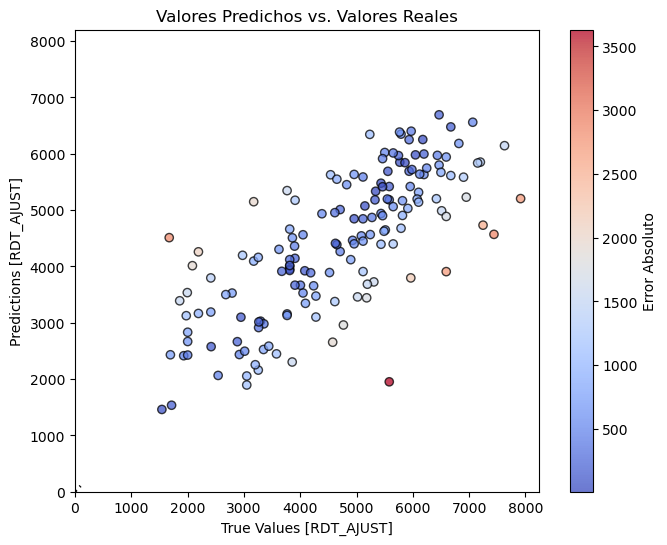

In [97]:
# Metricas
# =============================================
loss, mae, mse = model.evaluate(X_test, y_test, verbose=2)
print("Testing set Mean Abs Error: {:5.2f} MAE".format(mae))


# Predicciones
# ===============================================

# Finalmente se realizan las predicciónes
y_pred= model.predict(X_test).flatten()
df_metricas = calcular_metricas(y_pred, y_test)
print(df_metricas)


# Grafico
# ===========================================
scater_predictions(y_test, y_pred)


## 2. Dataset con las 20 caracteristicas mas relevantes 
**Nota** En este caso se toman las 20 caracteristicas mas relevantes, teniendo en cuenta la selección de atributos anteriormente realizada.


In [99]:

# Definición datos Train and Testo
# ===========================================

X_train_20, X_test_20, y_train_20, y_test_20 = procesamiento_features (X, Y ,features_20)
# Contrucción del modelo
# ===========================================
model_20 = build_model(X_train)
history_20, best_model_20 = entrenamiento_modelo(model_20, X_train_20, y_train_20)


Cantidad de caracteristicas:  20


C:\Users\germanm\AppData\Roaming\Python\Python39\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_27 (Dense)                │ (None, 64)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,569 (21.75 KB)

 Trainable params: 5,569 (21.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/1000
 1/16 ━━━━━━━━━━━━━━━━━━━━ 42s 3s/step - loss: 27870684.0000 - mae: 5093.1299 - mse: 27870684.0000
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 25384354.0000 - mae: 4847.2505 - mse: 25384354.0000 - val_loss: 24640668.0000 - val_mae: 4784.7764 - val_mse: 24640668.0000
Epoch 2/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 24750898.0000 - mae: 4777.8047 - mse: 24750898.0000 - val_loss: 24616914.0000 - val_mae: 4782.3223 - val_mse: 24616914.0000
Epoch 3/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 24178524.0000 - mae: 4717.3057 - mse: 24178524.0000 - val_loss: 24576844.0000 - val_mae: 4778.2158 - val_mse: 24576844.0000
Epoch 4/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 23585324.0000 - mae: 4656.0571 - mse: 23585324.0000 - val_loss: 24511640.0000 - val_mae: 4771.6167 - val_mse: 24511640.0000
Epoch 5/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 24158994.0000 - mae: 4734.6768 - mse: 24158994.0000 - val_loss: 24413152.0000 - val_mae: 4761.7617 - val

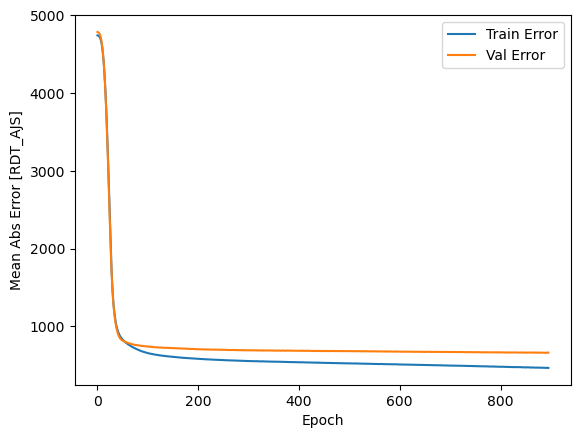

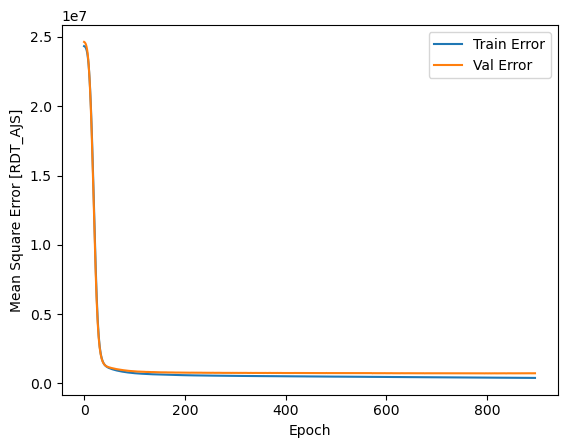

In [100]:
#  Resumen del entranamiento
# ========================================
hist = pd.DataFrame(history_20.history)
hist['epoch'] = history_20.epoch
hist.tail()

# Grafias de desempeño
# =========================================
plot_history(history_20)

5/5 - 0s - 15ms/step - loss: 979104.5000 - mae: 731.4496 - mse: 979104.5000
Testing set Mean Abs Error: 731.45 MAE
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step  
  Métrica          Valor
0      R²       0.429466
1     MAE     731.449633
2     MSE  979104.469905


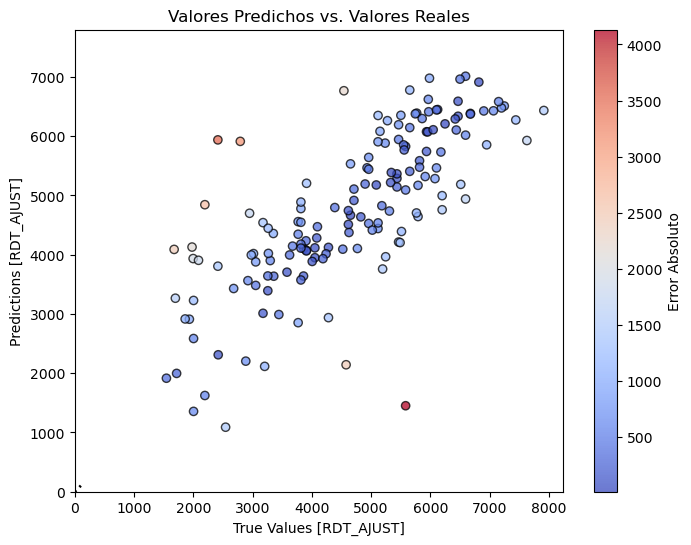

In [101]:
# Metricas
# =============================================
loss, mae, mse = best_model_20.evaluate(X_test_20, y_test_20, verbose=2)
print("Testing set Mean Abs Error: {:5.2f} MAE".format(mae))


# Predicciones
# ===============================================

# Finalmente se realizan las predicciónes
y_pred_20= best_model_20.predict(X_test_20).flatten()
df_metricas = calcular_metricas(y_pred_20, y_test_20)
print(df_metricas)


# Grafico
# ===========================================
scater_predictions(y_test_20, y_pred_20)